The AB test is a randomized experiment that is used by most large companies to evaluate the launch of new functionality. Various difficulties may arise in the analysis and conduct of the experiment. Several typical problematic cases from real life are given in this dataset and analysis.

### Content
1. [Loading and processing data](#Loading)
2. [Statistical Analysis](#Statistical)
3. [Conclusions](#Conclusions)

### Loading and processing data <a name="Loading"/>

Let's import the necessary libraries and load the data

In [5]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import shapiro

In [6]:
df =pd.read_csv('/content/sample_data/AB_Test_Results.csv')

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# TODO : take a quick look at the data
df.head(10)

,USER_ID,VARIANT_NAME,REVENUE
0,737,variant,0.0
1,2423,control,0.0
2,9411,control,0.0
3,7311,control,0.0
4,6174,variant,0.0
5,2380,variant,0.0
6,2849,control,0.0
7,9168,control,0.0
8,6205,variant,0.0
9,7548,control,0.0


Let's see if there are users who have two A/B test groups

In [9]:
# TODO : Look at the distribution of the number of unique groups for each user
df.groupby('USER_ID')['VARIANT_NAME'].nunique().value_counts()



,count
VARIANT_NAME,
1,4783
2,1541


In [10]:
# TODO : Look at the distribution of the number of unique groups for each user in relative terms
df.groupby('USER_ID')['VARIANT_NAME'].nunique().value_counts(normalize=True)*100


,proportion
VARIANT_NAME,
1,75.632511
2,24.367489


What can you observe ? Should we exclude these users ? Why ?

In [11]:
# TODO : users have 1 A/B test group ? No



# TODO : Take only these users
count_user= df.groupby('USER_ID')['VARIANT_NAME'].nunique()
count_user



,VARIANT_NAME
USER_ID,
2,1
3,2
4,1
5,1
6,1
...,...
9993,1
9995,1
9996,2


In [12]:
# TODO : Leave only records with users with the 1st ab test group
count_idx = count_user[count_user == 1].index
df_clean = df[df['USER_ID'].isin(count_idx)]
df_clean.head()


# TODO : Check that the number of users matches what it was before the exception
df_clean.groupby('USER_ID')['VARIANT_NAME'].nunique().value_counts()

,count
VARIANT_NAME,
1,4783


Let's see how the data is distributed

<Axes: xlabel='VARIANT_NAME', ylabel='REVENUE'>

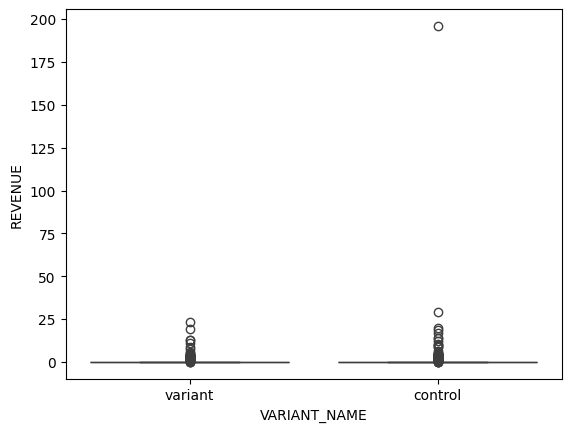

In [13]:
# TODO : Check how the data is distributed using a box plot
sns.boxplot(x='VARIANT_NAME', y='REVENUE', data=df_clean)


It can be seen that there is a strong outlier in the data - we will find it by sorting these revenue values in descending order

In [14]:
# TODO : Sort these revenue values in descending order
df_clean.sort_values(by='REVENUE', ascending=False)

,USER_ID,VARIANT_NAME,REVENUE
1437,3342,control,196.01
8168,2166,control,29.32
2482,7356,variant,23.04
6412,1053,control,20.07
5217,3684,variant,19.47
...,...,...,...
3400,9003,variant,0.00
3401,9902,variant,0.00
3403,4863,control,0.00
3404,1807,control,0.00


In [15]:
# TODO : See if user 3342 had other events with a strong outlier
df_clean[df_clean['USER_ID'] == 3342]


,USER_ID,VARIANT_NAME,REVENUE
1437,3342,control,196.01


We see that there is only one outlier - in conditions of limited information, we will remove this entry and look at the distribution of data again

In [16]:
# TODO : We see that there is only one outlier - in conditions of limited information, remove this entry and visualize the distribution of data again.
df_clean = df_clean[df_clean['USER_ID'] != 3342]


What can you say about the users and their purchases ?

In [17]:
# TODO : Check if there are users who have records with zero and positive revenue
check=df_clean.groupby('USER_ID')['REVENUE'].agg(['min', 'max'])
both_rev =check[(check['min']==0) &(check['max']>0)]
print(f' {len(both_rev)} users have records with zero and positive revenue')




 37 users have records with zero and positive revenue


Can a user have records with both zero and positive revenue ?

Let's make the assumption that the records are user visits to the service, and the experimental unit is users.


In [18]:
# TODO : Group the data for each user and sum the revenue for each to get one record per user
df_clean = df_clean.groupby('USER_ID').agg({'VARIANT_NAME':'first', 'REVENUE':'sum'})
df_clean.head()

,VARIANT_NAME,REVENUE
USER_ID,,
2,control,0.0
4,variant,0.0
5,variant,0.0
6,variant,0.0
9,variant,0.0


<Axes: xlabel='VARIANT_NAME', ylabel='REVENUE'>

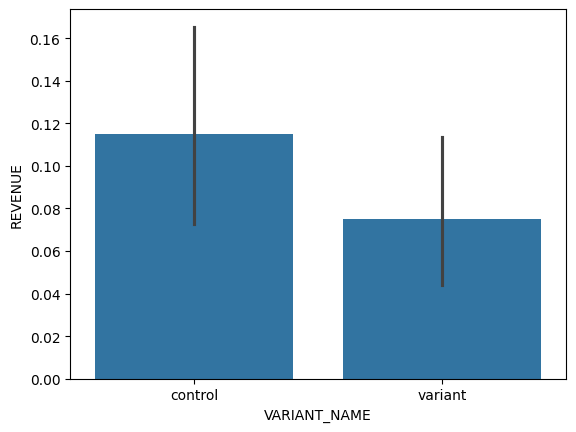

In [19]:
# TODO : Visualize the resulting distribution of the data again.
sns.barplot(x='VARIANT_NAME', y='REVENUE', data=df_clean)



In [20]:
df_clean.describe()

,REVENUE
count,4782.000000
mean,0.094912
std,1.021705
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,29.320000


It should be noted that during the transformation, the quantiles in the test group increased

It can be seen that in the test group, almost all quantile statistics, except for the minimum, are at a slightly lower level.

Let's look at various statistics in the context of AB test groups for all users

In [21]:
df_clean =df_clean.reset_index()
df_clean.head()

,USER_ID,VARIANT_NAME,REVENUE
0,2,control,0.0
1,4,variant,0.0
2,5,variant,0.0
3,6,variant,0.0
4,9,variant,0.0


In [22]:
# TODO : get metrics by groups
metrics =df_clean.groupby('VARIANT_NAME')['REVENUE'].agg(['sum','mean', 'median', 'std', 'min', 'max'])

# TODO : create two additional metrics to see relative changes
conversion =df_clean[df_clean['REVENUE']>0].groupby('VARIANT_NAME')['USER_ID'].nunique()

total_users =df_clean.groupby('VARIANT_NAME')['USER_ID'].nunique()
metrics['conversion_rate']=conversion/total_users
metrics['arppu']=metrics['sum']/conversion
print(metrics.head())


# TODO : add them to the rest of the metrics in a separate group


                 sum      mean  median       std  min    max  conversion_rate  \
VARIANT_NAME                                                                    
control       274.55  0.114923     0.0  1.162495  0.0  29.32         0.022185   
variant       179.32  0.074935     0.0  0.858207  0.0  23.04         0.017551   

                 arppu  
VARIANT_NAME            
control       5.180189  
variant       4.269524  


What can you see in the test group about the total amount of revenue, the average check per user, and the number of orders per user slightly increased ?

Let's also see how paying users behave :

In [23]:
# TODO : get metrics by groups


# TODO : create two additional metrics to see relative changes


# TODO : add them to the rest of the metrics in a separate group


Let's look at the distributions of all and only paying users

/tmp/ipykernel_8002/4101851425.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[df['VARIANT_NAME'] == 'control', 'REVENUE'], ax = axes[0], label='control')
/tmp/ipykernel_8002/4101851425.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.loc[df['VARIANT_NAME'] == 'variant', 'REVENU

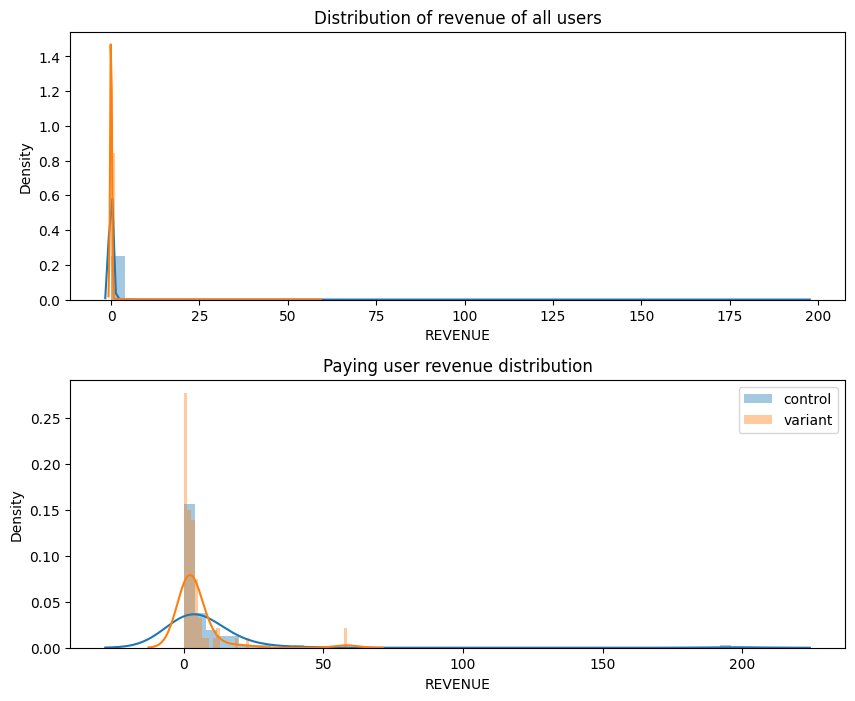

In [24]:
f, axes = plt.subplots(2, figsize=(10,8))
# build graphs of distributions of all users
sns.distplot(df.loc[df['VARIANT_NAME'] == 'control', 'REVENUE'], ax = axes[0], label='control')
sns.distplot(df.loc[df['VARIANT_NAME'] == 'variant', 'REVENUE'], ax = axes[0], label='variant')
axes[0].set_title('Distribution of revenue of all users')

# build graphs of distributions of paying users
sns.distplot(df.loc[(df['VARIANT_NAME'] == 'control') & (df['REVENUE'] > 0), 'REVENUE'], ax = axes[1], label='control' )
sns.distplot(df.loc[(df['VARIANT_NAME'] == 'variant') & (df['REVENUE'] > 0), 'REVENUE'], ax = axes[1], label='variant' )
axes[1].set_title('Paying user revenue distribution')
plt.legend()
plt.subplots_adjust(hspace = 0.3)

### Statistical Analysis <a name="Statistical"/>

#### Checking if the distribution is normal

Based on their previous graph, we see that the data is not normally distributed.

In [26]:
# TODO : Use the Shapiro-Wilk criterion to confirm it
control_revenue = df_clean[df_clean['VARIANT_NAME'] == 'control']['REVENUE'].values
variant_revenue = df_clean[df_clean['VARIANT_NAME'] == 'variant']['REVENUE'].values

print(f"Control: {len(control_revenue)} users")
print(f"Variant: {len(variant_revenue)} users")

# 2. Shapiro-Wilk test
for name, data in [("Control", control_revenue), ("Variant", variant_revenue)]:
  stat, p = shapiro(data)
  result = "REJECT normality" if p < 0.05 else "Cannot reject normality"
  print(f"\n{name}: W={stat:.4f}, p={p:.6f} -> {result}")



Control: 2389 users
Variant: 2393 users

Control: W=0.0746, p=0.000000 -> REJECT normality

Variant: W=0.0615, p=0.000000 -> REJECT normality


Is the null hypothesis about the normal distribution of the data rejected ?

#### Mann-Whitney test

Let's check the value of the statistics of the Mann-Whitney test. Some sources have a limitation of applicability in case of duplicate data. There are a lot of repetitions in our sample, and especially a lot of zero values, so in this case we need to be careful about this criterion.

In [27]:
(df['REVENUE'] == 0).value_counts()

,count
REVENUE,
True,9848
False,152


In [28]:
# TODO : Check on the data of all users the value of the statistics of the Mann-Whitney test
u_stat, mw_p = mannwhitneyu(control_revenue, variant_revenue)
print(f"\nMann-Whitney U: t={u_stat:.4f}, p={mw_p:.4f}")
print(f" -> {'Significant' if mw_p < 0.05 else 'NOT significant'}")



Mann-Whitney U: t=2871768.0000, p=0.2480
 -> NOT significant


In [29]:
# TODO : Check on the data of only the users that pay, the value of the statistics of the Mann-Whitney test
control_revenue_paid = df_clean[(df_clean['VARIANT_NAME'] == 'control') & (df_clean['REVENUE'] > 0)]['REVENUE'].values
variant_revenue_paid = df_clean[(df_clean['VARIANT_NAME'] == 'variant') & (df_clean['REVENUE'] > 0)]['REVENUE'].values
u_stat, mw_p = mannwhitneyu(control_revenue_paid, variant_revenue_paid)
print(f"\nMann-Whitney U: t={u_stat:.4f}, p={mw_p:.4f}")
print(f" -> {'Significant' if mw_p < 0.05 else 'NOT significant'}")





Mann-Whitney U: t=1197.0000, p=0.5314
 -> NOT significant


#### Bootstrap

In order to get more complete information about the differences between the average values of the ab test groups, we will use bootstap.

Let's create a function to get back samples and get a confidence interval, and then look at the sample statistics

In [30]:

def get_bootstrap_samples(data, n_samples=1000):
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples

def stat_intervals(stat, alpha=0.05):
    boundaries = np.percentile(stat, [100 * alpha / 2., 100 * (1 - alpha / 2.)])
    return boundaries

In [44]:
# TODO : Generate samples for all users
control = df_clean[df_clean['VARIANT_NAME'] == 'control']['REVENUE'].reset_index()
variant = df_clean[df_clean['VARIANT_NAME'] == 'variant']['REVENUE'].reset_index()
control

,index,REVENUE
0,0,0.0
1,5,0.0
2,6,0.0
3,7,0.0
4,11,0.0
...,...,...
2384,4773,0.0
2385,4776,0.0
2386,4778,0.0
2387,4779,0.0


In [39]:
# TODO : Generate samples for only paying users
control_paid = df_clean[(df_clean['VARIANT_NAME'] == 'control') & (df_clean['REVENUE'] > 0)]['REVENUE'].reset_index()
variant_paid = df_clean[(df_clean['VARIANT_NAME'] == 'variant') & (df_clean['REVENUE'] > 0)]['REVENUE'].reset_index


Let's look at the distribution of means in the ab test groups

/tmp/ipykernel_8002/2240544031.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(np.mean(control, axis=1), shade=True, label='control')
/tmp/ipykernel_8002/2240544031.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(np.mean(variant, axis=1), shade=True, label='variant')


Text(0.5, 1.0, 'Sample mean distribution for all users')

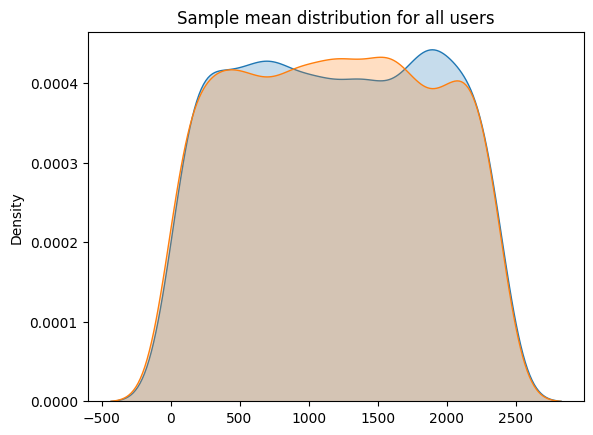

In [45]:
f, ax = plt.subplots()
# plt.figure(figsize=(20,5))
sns.kdeplot(np.mean(control, axis=1), shade=True, label='control')
sns.kdeplot(np.mean(variant, axis=1), shade=True, label='variant')
plt.title('Sample mean distribution for all users')

In [ ]:
f, ax = plt.subplots()
# plt.figure(figsize=(20,5))
sns.kdeplot(np.mean(control_paid, axis=1), shade=True, label='control')
sns.kdeplot(np.mean(variant_paid, axis=1), shade=True, label='variant')
plt.title('Sample mean distribution for paying users')

Do you see any difference ? What about the confidence intervals ? Conclude.

Let's evaluate the difference between the groups: look at the distribution of the mean difference and build confidence intervals for it. To do this, we will create a function for visualization

In [46]:
def plot_distribution_and_stat_intervals(variant, control, title, alpha=0.05):
    """ Plot the distribution of the mean difference and return the confidence intervals """
    f, ax = plt.subplots()
    # get data for coloring confidence intervals
    points = sns.kdeplot(variant - control, shade=True).get_lines()[0].get_data()
    x = points[0]
    y = points[1]
    ymin, ymax = plt.ylim()
    # highlight the zero value and the bounds of the confidence interval
    plt.vlines(0, 0, ymax, label='0', color='gray')
    plt.vlines(stat_intervals(variant - control, alpha)[0], 0, ymax, linestyles="dashed")
    plt.vlines(stat_intervals(variant - control, alpha)[1], 0, ymax, linestyles="dashed")
    # color the confidence interval and zones outside it
    plt.fill_between(x,y,
                     where = (x >= stat_intervals(variant - control, alpha)[1]),
                     color='gainsboro')
    plt.fill_between(x,y,
                     where = (x <= stat_intervals(variant - control, alpha)[0]),
                     color='gainsboro')
    plt.fill_between(x,y,
                     where = ((x >= stat_intervals(variant - control, alpha)[0])
                              & (x <= stat_intervals(variant - control, alpha)[1])),
                     color='red',
                     label = '95% confidence interval')
    plt.title(f'Distribution of difference between means (variant - control) {title}; {100*(1-alpha)}% Confidence interval for difference of means: {stat_intervals(variant - control, alpha)}')
    plt.legend(prop={'size':13})
    # return confidence interval data
    return stat_intervals(variant - control)

Let's build a graph of the distribution of the difference in the means and get a confidence interval

For all users

/tmp/ipykernel_8002/4111737823.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  points = sns.kdeplot(variant - control, shade=True).get_lines()[0].get_data()


IndexError: list index out of range

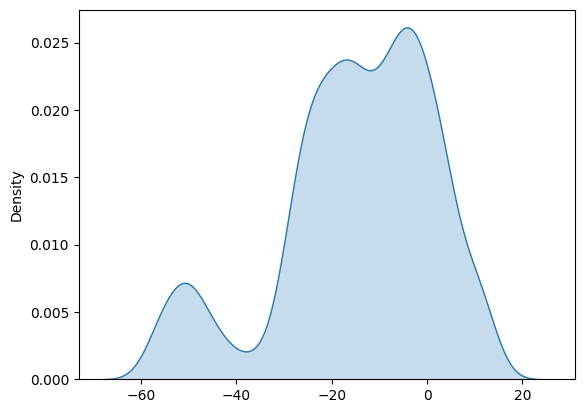

In [47]:
plot_distribution_and_stat_intervals(np.mean(variant, axis=1),
                                     np.mean(control, axis=1),
                                     title='all users')

In [ ]:
plot_distribution_and_stat_intervals(np.mean(variant_paid, axis=1),
                                     np.mean(control_paid, axis=1),
                                     title='paying users')

What can you observe ? Conclude about the statistical change in average revenue between A/B test groups.
